In [34]:
import sys
!{sys.executable} -m pip install pandas
!{sys.executable} -m pip install seaborn


81337.43s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


81343.09s - pydevd: Sending message related to process being replaced timed-out after 5 seconds


  Using cached seaborn-0.13.2-py3-none-any.whl.metadata (5.4 kB)
Using cached seaborn-0.13.2-py3-none-any.whl (294 kB)


In [ ]:
import sys
import numpy as np
import pandas as pd

pumpkins = pd.read_csv('/Users/semra/ML-For-Beginners/2-Regression/data/US-pumpkins.csv')

pumpkins = pumpkins[pumpkins["Package"].str.contains("bushel", case=True, regex=True)]
#Package sütununda “bushel” ifadesi geçen satırları filtreleyerek sadece bu satırları DataFrame’de tutar.
pumpkins.head() 

,City Name,Type,Package,Variety,Sub Variety,Grade,Date,Low Price,High Price,Mostly Low,...,Unit of Sale,Quality,Condition,Appearance,Storage,Crop,Repack,Trans Mode,Unnamed: 24,Unnamed: 25
70,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
71,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,9/24/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
72,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,18.0,18.0,18.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
73,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/1/16,17.0,17.0,17.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN
74,BALTIMORE,NaN,1 1/9 bushel cartons,PIE TYPE,NaN,NaN,10/8/16,15.0,15.0,15.0,...,NaN,NaN,NaN,NaN,NaN,NaN,N,NaN,NaN,NaN


In [9]:
pumpkins.isnull().sum()#veri setindeki eksik deger sayisi
#package date low price ve high price ile ilgileniyoruz 
# yılın her ayı için ortalama balkabagı fiyatını cıkarmak
# soru hangi ayda bal kabagı almak daha mantıklı

City Name            0
Type               406
Package              0
Variety              0
Sub Variety        167
Grade              415
Date                 0
Low Price            0
High Price           0
Mostly Low          24
Mostly High         24
Origin               0
Origin District    396
Item Size          114
Color              145
Environment        415
Unit of Sale       404
Quality            415
Condition          415
Appearance         415
Storage            415
Crop               415
Repack               0
Trans Mode         415
Unnamed: 24        415
Unnamed: 25        391
dtype: int64

In [10]:
new_columns = ['Package','Month', 'Low Price', 'High Price', 'Date']#ihtiyacımız olan sütunlar

#diğer sütunları kaldırıyoruz
pumpkins = pumpkins.drop([c for c in pumpkins.columns if c not in new_columns], axis=1) 
#axis = 1 sütun sileceğimizi belirtir

In [20]:
#ortalama fiyat hesaplama
price = (pumpkins['Low Price'] + pumpkins['High Price']) / 2

#date sütunundan ay bilgisi alma
month = pd.DatetimeIndex(pumpkins['Date']).month

#bunlarla yeni data oluştur
new_pumpkins = pd.DataFrame({'Month': month, 'Package': pumpkins['Package'], 'Low Price': pumpkins['Low Price'], 'High Price': pumpkins['High Price'], 'Price': price})

In [ ]:
#butun hucrelerdeki fiyatı 1/9 bushel e göre ayarlama normalizasyon
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1 1/9'),'Price'] = price/(1+1/9)
#butun hucrelerdeki fiyatı 1/2 bushel e göre ayarlama
new_pumpkins.loc[new_pumpkins['Package'].str.contains('1/2'), 'Price'] = price/(1/2)



In [28]:
new_pumpkins.head()

,Month,Package,Low Price,High Price,Price
70,9,1 1/9 bushel cartons,15.0,15.0,13.5
71,9,1 1/9 bushel cartons,18.0,18.0,16.2
72,10,1 1/9 bushel cartons,18.0,18.0,16.2
73,10,1 1/9 bushel cartons,17.0,17.0,15.3
74,10,1 1/9 bushel cartons,15.0,15.0,13.5


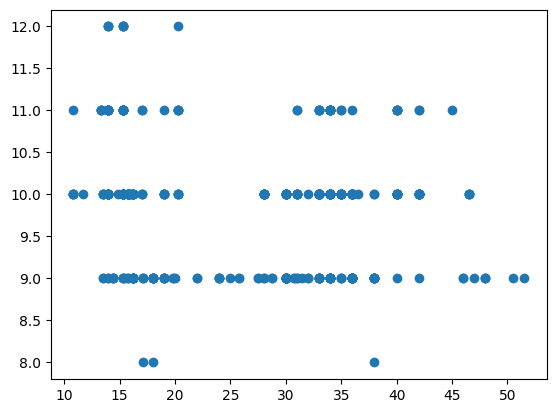

In [30]:
import matplotlib.pyplot as plt
#gorselleştirmek istenen verileri alalım
price = new_pumpkins.Price
month = new_pumpkins.Month

plt.scatter(price,month)
plt.show()

Text(0, 0.5, 'pumpkin price')

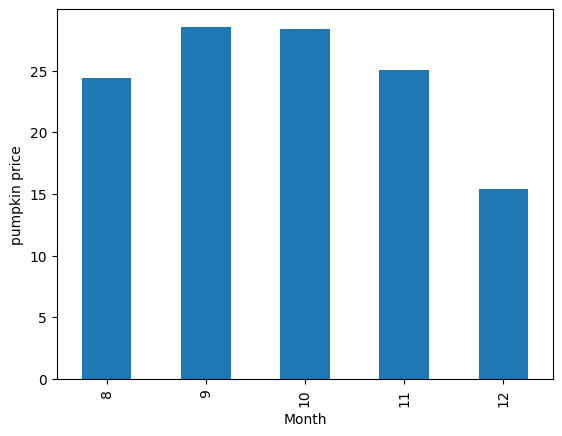

In [32]:
#ay ve fiyata gore balkabaklarını grupla
new_pumpkins.groupby(['Month'])['Price'].mean().plot(kind='bar')

plt.ylabel('pumpkin price')

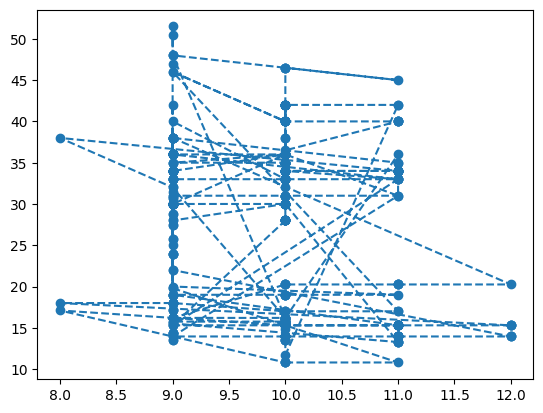

In [ ]:
import seaborn as sns
plt.plot(new_pumpkins['Month'],new_pumpkins['Price'], data=new_pumpkins, marker='o', linestyle='--')

<BarContainer object of 415 artists>

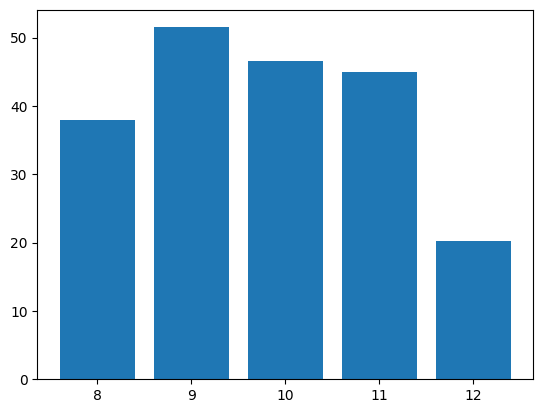

In [47]:
plt.bar(new_pumpkins['Month'],new_pumpkins['Price'])

(array([ 6., 10., 28., 67.,  9.,  8., 23.,  0.,  2.,  4.,  1.,  2., 14.,
         2., 48.,  4., 40., 55., 38.,  0., 10., 15., 16.,  0.,  0.,  3.,
         5.,  3.,  0.,  2.]),
 array([10.8       , 12.15666667, 13.51333333, 14.87      , 16.22666667,
        17.58333333, 18.94      , 20.29666667, 21.65333333, 23.01      ,
        24.36666667, 25.72333333, 27.08      , 28.43666667, 29.79333333,
        31.15      , 32.50666667, 33.86333333, 35.22      , 36.57666667,
        37.93333333, 39.29      , 40.64666667, 42.00333333, 43.36      ,
        44.71666667, 46.07333333, 47.43      , 48.78666667, 50.14333333,
        51.5       ]),
 <BarContainer object of 30 artists>)

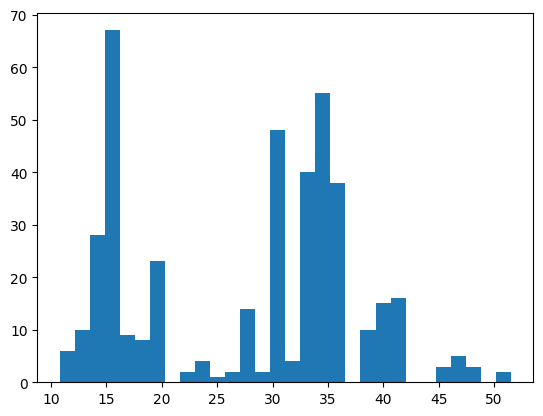

In [49]:
plt.hist(new_pumpkins['Price'], bins=30)

{'whiskers': [<matplotlib.lines.Line2D at 0x14240e480>,
 'caps': [<matplotlib.lines.Line2D at 0x14240e720>,
 'boxes': [<matplotlib.lines.Line2D at 0x14240f380>],
 'medians': [<matplotlib.lines.Line2D at 0x1430c78f0>],
 'fliers': [<matplotlib.lines.Line2D at 0x1430c6ae0>],
 'means': []}

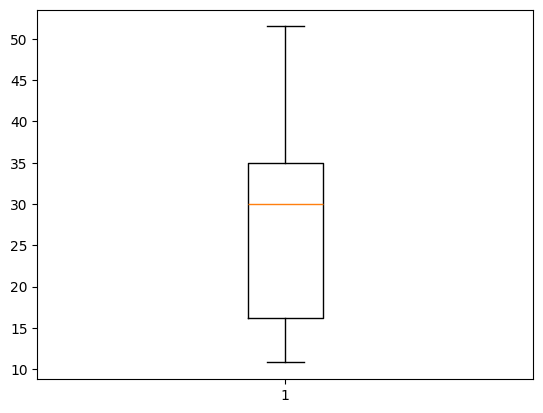

In [51]:
plt.boxplot(new_pumpkins['Price'])

<Axes: xlabel='Month', ylabel='Price'>

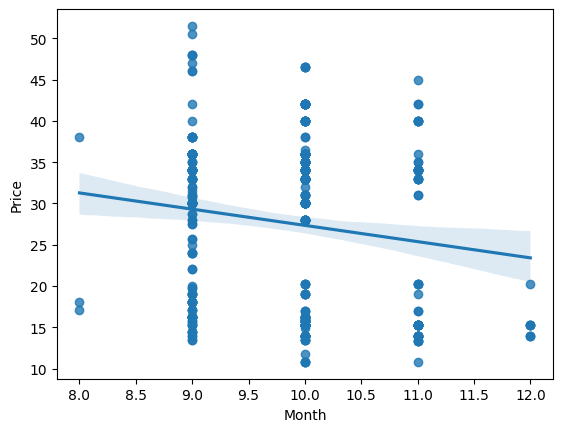

In [52]:
sns.regplot(x='Month', y='Price', data=new_pumpkins)

<Axes: xlabel='Month', ylabel='Price'>

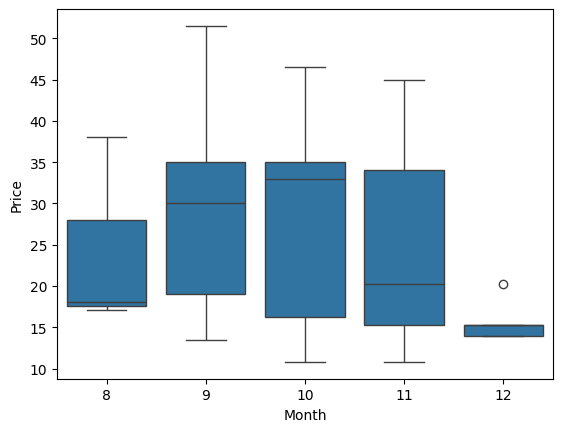

In [53]:
sns.boxplot(x='Month', y='Price', data=new_pumpkins)

<Axes: xlabel='Price', ylabel='Count'>

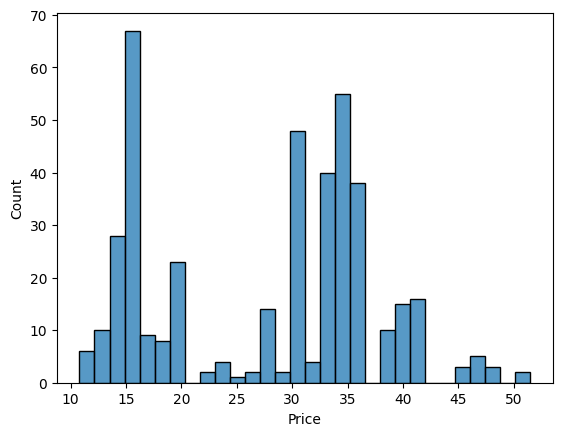

In [54]:
sns.histplot(new_pumpkins['Price'], bins=30)